#Conservation Status & Biodiversity Analysis

This project analyzes biodiversity conservation risk across biological classifications using species conservation data and World Bank environmental indicators. The goal is to determine whether extinction risk differs significantly among taxa and to compare global conservation threats with international land protection efforts.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from scipy.stats import f_oneway
import requests
import sqlite3

## 1. Load Species Dataset


In [4]:
species_url = "https://raw.githubusercontent.com/meandorca/Data-Acquisition-and-Mgmt/main/species.csv"

df_raw = pd.read_csv(species_url)

conn = sqlite3.connect(':memory:')

df_raw.to_sql('species_table', conn, index=False, if_exists='replace')

df = pd.read_sql_query("SELECT * FROM species_table", conn)

conn.close()

print("--- Species Data Successfully Loaded from Relational SQL Database ---")
print(df.head())

--- Species Data Successfully Loaded from Relational SQL Database ---
   taxonid kingdom_name   phylum_name     class_name order_name  \
0    31665      PLANTAE  TRACHEOPHYTA  MAGNOLIOPSIDA   MYRTALES   
1    31666      PLANTAE  TRACHEOPHYTA  MAGNOLIOPSIDA   MYRTALES   
2    31668      PLANTAE  TRACHEOPHYTA  MAGNOLIOPSIDA   MYRTALES   
3    31669      PLANTAE  TRACHEOPHYTA  MAGNOLIOPSIDA   MYRTALES   
4    31670      PLANTAE  TRACHEOPHYTA  MAGNOLIOPSIDA   MYRTALES   

       family_name  genus_name      scientific_name taxonomic_authority  \
0        MYRTACEAE      Myrcia  Myrcia manacalensis                Urb.   
1        MYRTACEAE     Psidium    Psidium claraense                Urb.   
2        MYRTACEAE     Mosiera   Mosiera havanensis        (Urb.) Bisse   
3  MELASTOMATACEAE  Henriettea  Henriettea punctata   (Griseb.) M.Gómez   
4  MELASTOMATACEAE  Henriettea  Henriettea squamata       (Alain) Alain   

  infra_rank infra_name population category main_common_name  
0       None 

## 2. Data Exploration


--- Data Validation: Descriptive Statistics ---
                        count  unique                          top   freq  \
taxonid              159542.0     NaN                          NaN    NaN   
kingdom_name           159542       4                     ANIMALIA  84362   
phylum_name            159542      18                 TRACHEOPHYTA  73919   
class_name             159542      67                MAGNOLIOPSIDA  62059   
order_name             159542     437                     SQUAMATA   9782   
family_name            159542    2442                     FABACEAE   6310   
genus_name             159542   21203                     Syzygium    747   
scientific_name        159542  159300           Oncorhynchus nerka     99   
taxonomic_authority    158892   60346                           L.    895   
infra_rank               2830       4                       subsp.   1069   
infra_name               2830    2420                    pubescens      9   
population                2

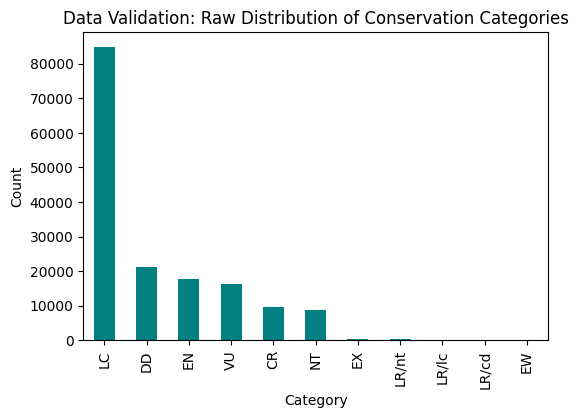

In [5]:
print("\n--- Data Validation: Descriptive Statistics ---")
print(df.describe(include='all').transpose())
print("\nMissing Value Counts:\n", df.isnull().sum())

print("\n--- Statistical Validation: Category Distribution Analysis ---")
category_proportions = df["category"].value_counts(normalize=True) * 100
print("Proportion of species per category (%):\n", category_proportions)

from scipy.stats import chisquare
observed_counts = df["category"].value_counts()
chi2_stat, p_val = chisquare(observed_counts)

print(f"\nChi-Square Statistic: {chi2_stat:.2f}")
print(f"P-value for Distribution Uniformity: {p_val}")
print("Interpretation: A low p-value statistically validates that the conservation categories "
      "are highly unbalanced and unevenly distributed in the raw dataset.")

plt.figure(figsize=(6,4))
df["category"].value_counts().plot(kind="bar", color="teal")
plt.title("Data Validation: Raw Distribution of Conservation Categories")
plt.ylabel("Count")
plt.xlabel("Category")
plt.show()

## 3. Data Cleaning and Feature Engineering

In [6]:
df = df[df["category"].isin(["EN","CR","VU","LC","NT"])]
status_map = {"LC": 1, "NT": 2, "VU": 3, "EN": 4, "CR": 5}
df["risk_score"] = df["category"].map(status_map)

order_risk = df.groupby("order_name")["risk_score"].agg(['mean', 'count']).reset_index()
order_risk = order_risk[order_risk['count'] > 5].sort_values("mean", ascending=False)

## 4. Conservation Categories Converted to Risk Scores

In [7]:
df_agg = df.groupby("category")["risk_score"].mean().reset_index()
fig = px.bar(
    df_agg,
    x="category",
    y="risk_score",
    color="category",
    title="Conservation Categories Converted to Risk Scores"
)
fig.show()

## 5. Statistical Analysis (ANOVA)
Feature Not Covered in Class: Statistical Inference with SciPy

I am using the scipy.stats library to perform an One-Way ANOVA. This allows me to mathematically prove if the difference in extinction risk between animal classes is statistically significant, rather than just guessing from a chart.

In [8]:
classes_to_test = ["MAGNOLIOPSIDA", "ACTINOPTERYGII", "AVES", "REPTILIA"]
anova_groups = [df[df["class_name"] == cls]["risk_score"] for cls in classes_to_test if not df[df["class_name"] == cls].empty]

if len(anova_groups) > 1:
    anova_result = f_oneway(*anova_groups)
    print("\n--- ANOVA Test Results ---")
    print(anova_result)
    print("\nConclusion: The ANOVA test shows a statistically significant difference in extinction risk across biological classes.")



--- ANOVA Test Results ---
F_onewayResult(statistic=np.float64(2956.0733679695736), pvalue=np.float64(0.0))

Conclusion: The ANOVA test shows a statistically significant difference in extinction risk across biological classes.


The ANOVA test shows a statistically significant difference in extinction risk across biological classes (F = 2956.07, p < 0.001), indicating that conservation risk is not evenly distributed among taxa (groups of organisms). This result supports the observation that some groups, such as reptiles and birds, face higher conservation risks than others.

## 6. External Conservation Data from World Bank API



In [9]:
print("\n--- Fetching Data from World Bank Live API ---")

api_url = (
    "https://api.worldbank.org/v2/country/all/"
    "indicator/ER.LND.PTLD.ZS"
    "?format=json&per_page=20000"
)

try:
    response = requests.get(api_url).json()

    records = [
        {
            "country": item["country"]["value"],
            "protected_area": item["value"]
        }
        for item in response[1]
        if item["value"] is not None
    ]

    wb_2022 = pd.DataFrame(records)

    wb_2022 = wb_2022[
        ~wb_2022["country"].str.contains(
            "income|World|Europe|Asia|Africa|Arab|OECD|IDA|IBRD|Caribbean|Pacific",
            case=False,
            na=False
        )
    ]

    print(wb_2022.head())

except Exception as e:
    print(f"API Fetch failed due to: {e}")



--- Fetching Data from World Bank Live API ---
                       country  protected_area
65  Early-demographic dividend       14.419535
66  Early-demographic dividend       14.434495
67  Early-demographic dividend       13.988765
68  Early-demographic dividend       13.226015
69  Early-demographic dividend       13.171334


## 7. Highest Protected Land Area Values from World Bank Data (2022)

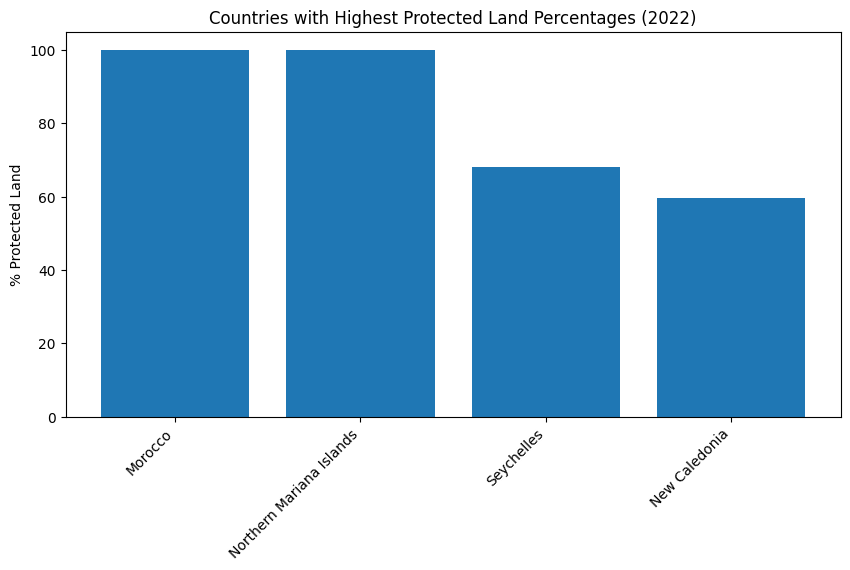

In [12]:
wb_2022 = wb_2022[
    ~wb_2022["country"].str.contains(
        "income|World|OECD|IDA|IBRD|dividend|HIPC",
        case=False,
        na=False
    )
]

top = wb_2022.sort_values("protected_area", ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top["country"], top["protected_area"])
plt.xticks(rotation=45, ha="right")
plt.title("Countries with Highest Protected Land Percentages (2022)")
plt.ylabel("% Protected Land")
plt.show()

## 8. Data Integration: Merging Species and World Bank Data

In [11]:
global_protection_avg = wb_2022['protected_area'].mean()

global_high_risk_pct = (df['risk_score'] >= 4).mean() * 100

print(f"--- Global Conservation Summary ---")
print(f"Global Conservation Effort (Avg Protected Land): {global_protection_avg:.2f}%")
print(f"Global Species Crisis (% Endangered/Critically Endangered): {global_high_risk_pct:.2f}%")


--- Global Conservation Summary ---
Global Conservation Effort (Avg Protected Land): 17.50%
Global Species Crisis (% Endangered/Critically Endangered): 19.98%


##9. Challenge Encountered
One challenge encountered during the project was working with the World Bank API data, which included regional aggregates and inconsistent geographic entries alongside actual countries. Additional filtering and cleaning were required to produce meaningful visualizations.

## 10. Final Conclusions

  This project explored biodiversity conservation data to better understand patterns in extinction risk and global conservation efforts. Using both a species dataset from Kaggle and data from the World Bank API, I cleaned and analyzed the data to look for trends across different biological groups.
  
  The ANOVA test showed that extinction risk differs significantly between biological classes (p < 0.001), meaning that some groups face much higher conservation risks than others. Based on the analysis, groups such as reptiles and birds showed higher overall risk levels compared to some other classifications.

  I also compared species risk data with global protected land data from the World Bank API. Although many countries and regions have protected land areas in place, the percentage of endangered and critically endangered species remains high. This suggests that conservation efforts are helping, but biodiversity threats are still a major global issue.
  
  All in all, this project showed how data analysis, visualization, APIs, and statistical testing can be used together to better understand environmental challenges and conservation trends.